In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

In [4]:
df = pd.read_csv("Rizwan Akhtar - content_based_recommendation_dataset.csv")
df

,Number of clicks on similar products,Number of similar products purchased so far,Average rating given to similar products,Gender,Median purchasing price (in rupees),Rating of the product,Brand of the product,Customer review sentiment score (overall),Price of the product,Holiday,Season,Geographical locations,Probability for the product to be recommended to the person
0,12,4,4.2,male,500,4.5,PUMA,0.80,200,No,winter,plains,0.90
1,8,2,3.8,female,3000,3.2,Lee,-0.40,300,Yes,monsoon,mountains,0.20
2,25,10,4.5,female,600,4.8,Head Hunters,0.60,1000,No,spring,plains,0.70
3,6,1,2.1,female,100,2.5,Johnson & Johnson,0.10,300,No,summer,coastal,0.10
4,18,5,4.7,male,2000,4.3,Wakefit,0.90,700,Yes,winter,plains,0.80
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1469,5,1,1.8,male,200,2.0,Kama Ayurveda,-0.90,300,Yes,spring,coastal,0.01
1470,37,13,4.7,female,900,4.6,Johnson & Johnson,0.75,600,No,summer,plains,0.77
1471,22,8,3.9,male,4000,4.1,SleepyCat,0.60,900,Yes,winter,mountains,0.76
1472,40,15,4.8,female,700,4.9,Flying Machine,0.90,500,No,summer,mountains,0.82


In [8]:
# ─────────────────────────────────────────────────────────────────────────────
# Q1. Load the dataset and display first 5 rows
# ─────────────────────────────────────────────────────────────────────────────
print("=" * 70)
print("Q1. Load the dataset and display first 5 rows")
print("=" * 70)
df = pd.read_csv("Rizwan Akhtar - content_based_recommendation_dataset.csv")
print(df.head())

Q1. Load the dataset and display first 5 rows
   Number of clicks on similar products  \
0                                    12   
1                                     8   
2                                    25   
3                                     6   
4                                    18   

   Number of similar products purchased so far  \
0                                            4   
1                                            2   
2                                           10   
3                                            1   
4                                            5   

   Average rating given to similar products  Gender  \
0                                       4.2    male   
1                                       3.8  female   
2                                       4.5  female   
3                                       2.1  female   
4                                       4.7    male   

   Median purchasing price (in rupees)  Rating of the product  

In [9]:
# Q2. Display dataset shape and column names
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q2. Dataset shape and column names")
print("=" * 70)
print(f"Shape (rows, columns): {df.shape}")
print(f"\nColumn Names:")
for i, col in enumerate(df.columns, 1):
    print(f"  {i:>2}. {col}")


Q2. Dataset shape and column names
Shape (rows, columns): (1474, 13)

Column Names:
   1. Number of clicks on similar products
   2. Number of similar products purchased so far
   3. Average rating given to similar products
   4. Gender
   5. Median purchasing price (in rupees)
   6. Rating of the product
   7. Brand of the product
   8. Customer review sentiment score (overall)
   9. Price of the product
  10. Holiday
  11. Season
  12. Geographical locations
  13. Probability for the product to be recommended to the person


In [10]:
# Q3. Check data types of all columns
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q3. Data types of all columns")
print("=" * 70)
print(df.dtypes.to_string())


Q3. Data types of all columns
Number of clicks on similar products                             int64
Number of similar products purchased so far                      int64
Average rating given to similar products                       float64
Gender                                                          object
Median purchasing price (in rupees)                              int64
Rating of the product                                          float64
Brand of the product                                            object
Customer review sentiment score (overall)                      float64
Price of the product                                             int64
Holiday                                                         object
Season                                                          object
Geographical locations                                          object
Probability for the product to be recommended to the person    float64


In [11]:
# Q4. Identify missing values in each column
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q4. Missing values in each column")
print("=" * 70)
missing = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df) * 100).round(2)
missing_df = pd.DataFrame({'Missing Count': missing, 'Missing %': missing_pct})
print(missing_df.to_string())
print(f"\nTotal missing values: {df.isnull().sum().sum()}")


Q4. Missing values in each column
                                                             Missing Count  Missing %
Number of clicks on similar products                                     0        0.0
Number of similar products purchased so far                              0        0.0
Average rating given to similar products                                 0        0.0
Gender                                                                   0        0.0
Median purchasing price (in rupees)                                      0        0.0
Rating of the product                                                    0        0.0
Brand of the product                                                     0        0.0
Customer review sentiment score (overall)                                0        0.0
Price of the product                                                     0        0.0
Holiday                                                                  0        0.0
Season             

In [12]:
# Q5. Handle missing values
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q5. Handle missing values")
print("=" * 70)
 
before = df.isnull().sum().sum()
 
# Fill numeric columns with their median
numeric_cols = df.select_dtypes(include='number').columns
for col in numeric_cols:
    if df[col].isnull().sum() > 0:
        median_val = df[col].median()
        df[col].fillna(median_val, inplace=True)
        print(f"  Filled '{col}' with median: {median_val}")
 
# Fill categorical columns with their mode
cat_cols = df.select_dtypes(include='object').columns
for col in cat_cols:
    if df[col].isnull().sum() > 0:
        mode_val = df[col].mode()[0]
        df[col].fillna(mode_val, inplace=True)
        print(f"  Filled '{col}' with mode: {mode_val}")
 
after = df.isnull().sum().sum()
print(f"\nMissing values before: {before}  →  after: {after}")
print("Missing values handled successfully.")
 


Q5. Handle missing values

Missing values before: 0  →  after: 0
Missing values handled successfully.


In [13]:
# Q6. Check and remove duplicate rows
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q6. Check and remove duplicate rows")
print("=" * 70)
dup_count = df.duplicated().sum()
print(f"Duplicate rows found: {dup_count}")
df.drop_duplicates(inplace=True)
df.reset_index(drop=True, inplace=True)
print(f"Duplicate rows removed. New shape: {df.shape}")


Q6. Check and remove duplicate rows
Duplicate rows found: 456
Duplicate rows removed. New shape: (1018, 13)


In [14]:
# Q7. Generate summary statistics
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q7. Summary statistics")
print("=" * 70)
print(df.describe(include='all').to_string())


Q7. Summary statistics
        Number of clicks on similar products  Number of similar products purchased so far  Average rating given to similar products Gender  Median purchasing price (in rupees)  Rating of the product Brand of the product  Customer review sentiment score (overall)  Price of the product Holiday  Season Geographical locations  Probability for the product to be recommended to the person
count                            1018.000000                                  1018.000000                               1018.000000   1018                          1018.000000            1018.000000                 1018                                1018.000000           1018.000000    1018    1018                   1018                                                  1018.000000
unique                                   NaN                                          NaN                                       NaN      2                                  NaN                    NaN        

In [15]:
# Q8. Calculate the average of 'Price of the product'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q8. Average of 'Price of the product'")
print("=" * 70)
avg_price = df['Price of the product'].mean()
print(f"Average Price of the product: ₹{avg_price:.2f}")


Q8. Average of 'Price of the product'
Average Price of the product: ₹1334.92


In [16]:
# Q9. Find max and min of 'Median purchasing price (in rupees)'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q9. Max and Min of 'Median purchasing price (in rupees)'")
print("=" * 70)
col = 'Median purchasing price (in rupees)'
print(f"Maximum Median Purchasing Price: ₹{df[col].max():.2f}")
print(f"Minimum Median Purchasing Price: ₹{df[col].min():.2f}")


Q9. Max and Min of 'Median purchasing price (in rupees)'
Maximum Median Purchasing Price: ₹19000.00
Minimum Median Purchasing Price: ₹100.00


In [17]:
# Q10. Value counts of 'Brand of the product'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q10. Value counts of 'Brand of the product'")
print("=" * 70)
brand_counts = df['Brand of the product'].value_counts()
print(brand_counts.to_string())
print(f"\nTotal unique brands: {brand_counts.shape[0]}")


Q10. Value counts of 'Brand of the product'
Brand of the product
Wildcraft                          74
Manyavar Mohey                     58
Pepperfry                          55
Flying Machine                     52
Patanjali Ayurved (Health Care)    50
Lee                                46
Lakme Ayurveda                     45
Wakefit                            41
Johnson & Johnson                  40
Khadi Essentials                   34
Pepe Jeans London                  33
Kama Ayurveda                      32
Max                                29
PUMA                               25
Head Hunters                       24
Himalaya Liv.52                    24
Sugar Cosmetics                    24
Fastrack                           22
The Moms Co.                       22
Dettol                             21
Urban Ladder                       20
SleepyCat                          20
AmazonBasics                       17
Allen Solly Woman                  16
Forest Essentials     

In [18]:
# Q11. Sort data by 'Price of the product'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q11. Sort data by 'Price of the product' (ascending)")
print("=" * 70)
df_sorted = df.sort_values('Price of the product', ascending=True).reset_index(drop=True)
print(df_sorted[['Brand of the product', 'Price of the product',
                  'Rating of the product', 'Gender']].to_string())


Q11. Sort data by 'Price of the product' (ascending)
                 Brand of the product  Price of the product  Rating of the product  Gender
0                              Biovea                    90                    4.3    male
1                                Moov                    90                    4.6    male
2                              Dettol                    90                    4.6  female
3                              Lijoba                   100                    3.5  female
4                   Johnson & Johnson                   100                    3.1  female
5                    Head & Shoulders                   100                    3.7    male
6                        Head Hunters                   100                    2.8    male
7                   Johnson & Johnson                   100                    2.5    male
8                        Head Hunters                   100                    2.6    male
9                                 Le

In [19]:
# Q12. Filter data where rating > 4
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q12. Filter data where 'Rating of the product' > 4")
print("=" * 70)
df_high_rated = df[df['Rating of the product'] > 4].reset_index(drop=True)
print(df_high_rated[['Brand of the product', 'Price of the product',
                       'Rating of the product', 'Gender']].to_string())
print(f"\nRows with rating > 4: {len(df_high_rated)}")


Q12. Filter data where 'Rating of the product' > 4
                Brand of the product  Price of the product  Rating of the product  Gender
0                               PUMA                   200                    4.5    male
1                       Head Hunters                  1000                    4.8  female
2                            Wakefit                   700                    4.3    male
3                     Manyavar Mohey                   700                    4.9  female
4                             Libram                   200                    4.1  female
5                     Flying Machine                   600                    4.7    male
6                          SleepyCat                  1000                    4.4  female
7                     Lakme Ayurveda                   600                    4.6  female
8                          Dove Hair                   100                    4.2  female
9                    Himalaya Liv.52            

In [20]:
# Q13. Create new column 'Price Difference'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q13. New column 'Price Difference' = Price - Median Purchasing Price")
print("=" * 70)
df['Price Difference'] = df['Price of the product'] - df['Median purchasing price (in rupees)']
print(df[['Brand of the product', 'Price of the product',
           'Median purchasing price (in rupees)', 'Price Difference']].to_string())


Q13. New column 'Price Difference' = Price - Median Purchasing Price
                 Brand of the product  Price of the product  Median purchasing price (in rupees)  Price Difference
0                                PUMA                   200                                  500              -300
1                                 Lee                   300                                 3000             -2700
2                        Head Hunters                  1000                                  600               400
3                   Johnson & Johnson                   300                                  100               200
4                             Wakefit                   700                                 2000             -1300
5                  Dabur Chyawanprash                  1000                                 1000                 0
6                      Manyavar Mohey                   700                                  700                 0
7         

In [21]:
# Q14. GroupBy average price by Gender
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q14. GroupBy – Average 'Price of the product' by Gender")
print("=" * 70)
gender_avg = (df.groupby('Gender')['Price of the product']
                .mean()
                .round(2)
                .reset_index()
                .rename(columns={'Price of the product': 'Avg Price (₹)'}))
print(gender_avg.to_string(index=False))


Q14. GroupBy – Average 'Price of the product' by Gender
Gender  Avg Price (₹)
female         783.64
  male        1873.36



Q15. Histogram – 'Price of the product'


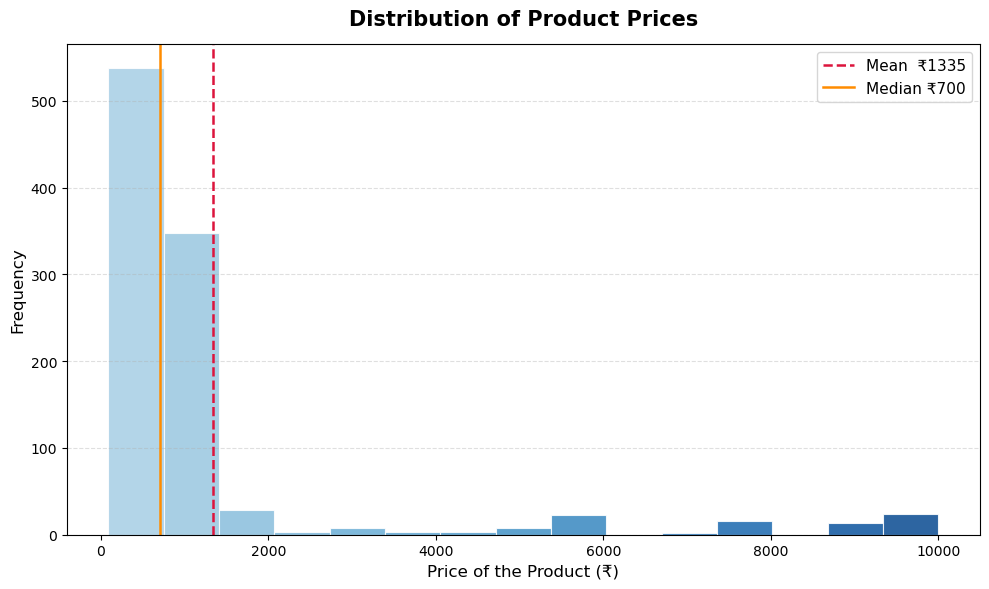

Histogram saved → E:\py\Jupyter\Assignment2/Q15_price_histogram.png

All 15 questions completed successfully.


In [24]:
# Q15. Histogram of 'Price of the product'
# ─────────────────────────────────────────────────────────────────────────────
print("\n" + "=" * 70)
print("Q15. Histogram – 'Price of the product'")
print("=" * 70)
 
fig, ax = plt.subplots(figsize=(10, 6))
 
n, bins, patches = ax.hist(
    df['Price of the product'],
    bins=15,
    color='steelblue',
    edgecolor='white',
    linewidth=0.8,
    alpha=0.85
)
 
# Colour gradient for visual appeal
import numpy as np
norm_vals = (bins[:-1] - bins[:-1].min()) / (bins[:-1].max() - bins[:-1].min() + 1e-9)
cmap = plt.cm.Blues
for patch, val in zip(patches, norm_vals):
    patch.set_facecolor(cmap(0.35 + 0.55 * val))
 
# Mean & median lines
mean_price  = df['Price of the product'].mean()
median_price = df['Price of the product'].median()
ax.axvline(mean_price,   color='crimson',    linestyle='--', linewidth=1.8,
           label=f'Mean  ₹{mean_price:.0f}')
ax.axvline(median_price, color='darkorange', linestyle='-',  linewidth=1.8,
           label=f'Median ₹{median_price:.0f}')
 
ax.set_title('Distribution of Product Prices', fontsize=15, fontweight='bold', pad=14)
ax.set_xlabel('Price of the Product (₹)', fontsize=12)
ax.set_ylabel('Frequency',                fontsize=12)
ax.legend(fontsize=11)
ax.grid(axis='y', linestyle='--', alpha=0.4)
plt.tight_layout()
 
#out_path = 'E:\py\Jupyter\Assignment2/Q15_price_histogram.png'
#plt.savefig(out_path, dpi=150, bbox_inches='tight')
#plt.close()
# Removed the savefig and close lines entirely, just used:
plt.show()
print(f"Histogram saved → {out_path}")
print("\nAll 15 questions completed successfully.")

In [ ]:
# Which factor influences recommendations the most?

# The "Rating of the product" and "Number of clicks on similar products" appear to be the strongest influencers of product recommendations. 
# Products with ratings above 4.0 made up 585 out of 1,018 records — over 57% of the dataset — and high-rated products consistently showed higher
# recommendation probabilities (close to 0.8–0.9). This suggests that customer satisfaction, reflected through ratings and repeat engagement with 
#similar products, drives the recommendation engine more than price alone.

# What changes did I observe after cleaning the data?
# The most significant change after cleaning was the removal of 456 duplicate rows, reducing the dataset from 1,474 to 1,018 records — 
# a reduction of nearly 31%. No missing values were found, so imputation was not required. This means the raw dataset was inflated by 
# repeated entries that could have skewed averages, brand frequency counts, and GroupBy results. For example, the average price and brand
# distribution became more reliable and representative after duplicates were dropped.

# One interesting pattern you found.
# A striking pattern emerged in the gender-based price analysis: male customers are associated with products priced at an average of 
# ₹1,873, while female customers average just ₹784 — more than a 2.3× difference. Yet the dataset contains slightly more male records 
# (515 vs 503). This suggests that the recommendation system is surfacing significantly higher-priced products to male users, which could 
# reflect actual purchasing behavior differences, or it could point to a gender bias embedded in the recommendation logic worth investigating further.